In [8]:
'''
AŞI VERİLERİ
total_vaccinations	Toplam yapılan doz sayısı (bir kişi 2 doz olduysa 2 sayılır)
people_vaccinated	En az 1 doz olan kişi sayısı
people_fully_vaccinated	Tam aşılı (2 doz vb.) kişi sayısı
total_boosters	Yapılan hatırlatma (booster) dozu sayısı
*_per_hundred uzantılı	Yüz kişi başına oran
'''

'\nAŞI VERİLERİ\ntotal_vaccinations\tToplam yapılan doz sayısı (bir kişi 2 doz olduysa 2 sayılır)\npeople_vaccinated\tEn az 1 doz olan kişi sayısı\npeople_fully_vaccinated\tTam aşılı (2 doz vb.) kişi sayısı\ntotal_boosters\tYapılan hatırlatma (booster) dozu sayısı\n*_per_hundred uzantılı\tYüz kişi başına oran\n'

In [95]:
#Aşılama verilerinin incelenmesi
vaccination_coverage = df_countries.groupby('location').agg(
    toplam_satir=('date', 'size'),
    ilk_doz_kaydi=('people_vaccinated_per_hundred', 'count'),
    tam_asi_kaydi=('people_fully_vaccinated_per_hundred', 'count')
)

vaccination_coverage['bos_ilk_doz_kaydi'] = (
    vaccination_coverage['toplam_satir']
    - vaccination_coverage['ilk_doz_kaydi']
)

vaccination_coverage['bos_tam_asi_kaydi'] = (
    vaccination_coverage['toplam_satir']
    - vaccination_coverage['tam_asi_kaydi']
)

print(
    vaccination_coverage
    .sort_values('tam_asi_kaydi')
    .head(15)
)

                          toplam_satir  ilk_doz_kaydi  tam_asi_kaydi  \
location                                                               
American Samoa                    1674              0              0   
Guadeloupe                        1674              0              0   
French Guiana                     1674              0              0   
Liechtenstein                     1674            420              0   
Guam                              1674              0              0   
Eritrea                           1674              0              0   
Puerto Rico                       1674              0              0   
Saint Barthelemy                  1674              0              0   
Palau                             1674              0              0   
Reunion                           1674              0              0   
Northern Mariana Islands          1674              0              0   
North Korea                       1674              0           

In [96]:
us_vaccination = df_countries.loc[
    df_countries['location'] == 'United States',
    ['date', 'people_vaccinated', 'people_fully_vaccinated']
].sort_values('date').copy()

us_vaccination['hafta_baslangici'] = (
    us_vaccination['date']
    - pd.to_timedelta(
        us_vaccination['date'].dt.dayofweek,
        unit='D'
    )
)

print(us_vaccination.head(10).to_string(index=False))

      date  people_vaccinated  people_fully_vaccinated hafta_baslangici
2020-01-05                NaN                      NaN       2019-12-30
2020-01-06                NaN                      NaN       2020-01-06
2020-01-07                NaN                      NaN       2020-01-06
2020-01-08                NaN                      NaN       2020-01-06
2020-01-09                NaN                      NaN       2020-01-06
2020-01-10                NaN                      NaN       2020-01-06
2020-01-11                NaN                      NaN       2020-01-06
2020-01-12                NaN                      NaN       2020-01-06
2020-01-13                NaN                      NaN       2020-01-13
2020-01-14                NaN                      NaN       2020-01-13


In [97]:
usa_vaccination_start = pd.Series({
    'ilk_doz_ilk_kayit': us_vaccination.loc[
        us_vaccination['people_vaccinated'].notna(),
        'date'
    ].min(),

    'tam_asi_ilk_kayit': us_vaccination.loc[
        us_vaccination['people_fully_vaccinated'].notna(),
        'date'
    ].min()
})

print(usa_vaccination_start)

ilk_doz_ilk_kayit   2020-12-13
tam_asi_ilk_kayit   2020-12-13
dtype: datetime64[ns]


In [98]:
usa_vaccination_start_period = us_vaccination.loc[
    us_vaccination['date'].between(
        '2020-12-13',
        '2021-01-10'
    ),
    ['date', 'people_vaccinated',
     'people_fully_vaccinated',
     'hafta_baslangici']
]

print(usa_vaccination_start_period.to_string(index=False))

      date  people_vaccinated  people_fully_vaccinated hafta_baslangici
2020-12-13            36817.0                   9669.0       2020-12-07
2020-12-14            41465.0                   9833.0       2020-12-14
2020-12-15            87883.0                  10161.0       2020-12-14
2020-12-16           243398.0                  10679.0       2020-12-14
2020-12-17           511644.0                  11505.0       2020-12-14
2020-12-18           923222.0                  12831.0       2020-12-14
2020-12-19          1103020.0                  13990.0       2020-12-14
2020-12-20          1207930.0                  14813.0       2020-12-14
2020-12-21          1587344.0                  16487.0       2020-12-21
2020-12-22          2029284.0                  19503.0       2020-12-21
2020-12-23          2595428.0                  22769.0       2020-12-21
2020-12-24          2788297.0                  24017.0       2020-12-21
2020-12-25          2800935.0                  24155.0       202

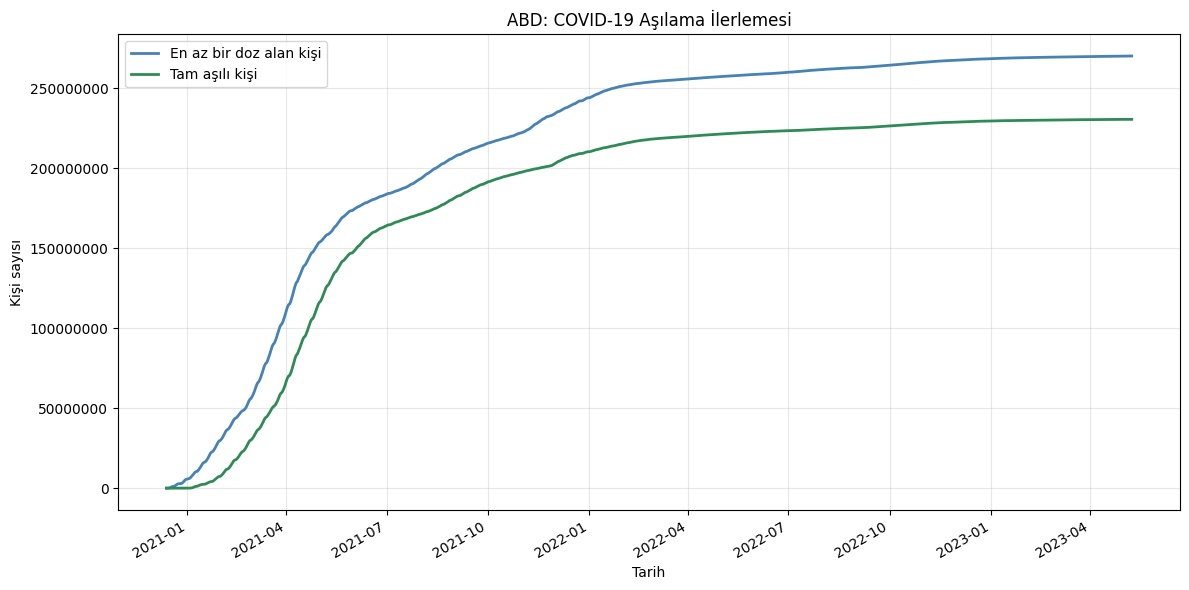

In [99]:
#ABD'de haftalık aşı nasıl değişmiş
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    us_vaccination['date'],
    us_vaccination['people_vaccinated'],
    label='En az bir doz alan kişi',
    color='steelblue',
    linewidth=2
)

ax.plot(
    us_vaccination['date'],
    us_vaccination['people_fully_vaccinated'],
    label='Tam aşılı kişi',
    color='seagreen',
    linewidth=2
)

ax.set_title('ABD: COVID-19 Aşılama İlerlemesi')
ax.set_xlabel('Tarih')
ax.set_ylabel('Kişi sayısı')

ax.ticklabel_format(axis='y', style='plain')
ax.grid(alpha=0.3)
ax.legend()

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [100]:
print('total_vaccinations' in df_countries.columns)

True


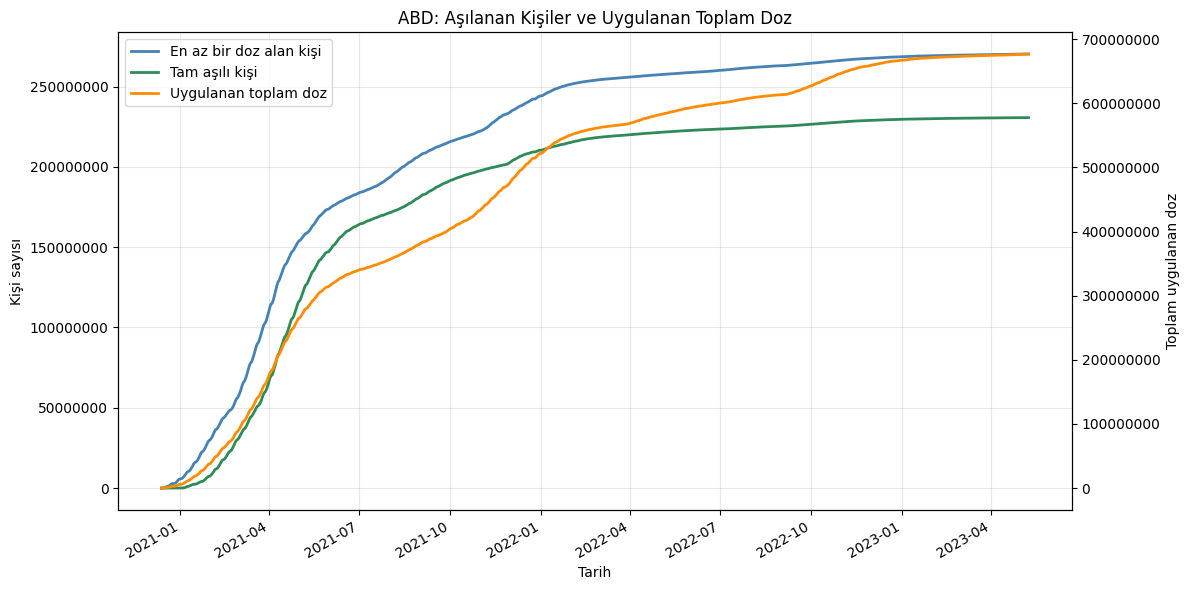

In [101]:
#toplam doz nası değişmiş,en az bir doz olanların sayısı,tam doz olanlar.
us_vaccination = (
    df_countries.loc[
        df_countries['location'].eq('United States'),
        [
            'date',
            'people_vaccinated',
            'people_fully_vaccinated',
            'total_vaccinations'
        ]
    ]
    .sort_values('date')
    .copy()
)

fig, ax_kisiler = plt.subplots(figsize=(12, 6))

# Sol eksen: kişi sayıları
ax_kisiler.plot(
    us_vaccination['date'],
    us_vaccination['people_vaccinated'],
    color='steelblue',
    linewidth=2,
    label='En az bir doz alan kişi'
)

ax_kisiler.plot(
    us_vaccination['date'],
    us_vaccination['people_fully_vaccinated'],
    color='seagreen',
    linewidth=2,
    label='Tam aşılı kişi'
)

ax_kisiler.set_xlabel('Tarih')
ax_kisiler.set_ylabel('Kişi sayısı')
ax_kisiler.ticklabel_format(axis='y', style='plain')
ax_kisiler.grid(alpha=0.3)

# Sağ eksen: toplam uygulanan doz
ax_dozlar = ax_kisiler.twinx()

ax_dozlar.plot(
    us_vaccination['date'],
    us_vaccination['total_vaccinations'],
    color='darkorange',
    linewidth=2,
    label='Uygulanan toplam doz'
)

ax_dozlar.set_ylabel('Toplam uygulanan doz')
ax_dozlar.ticklabel_format(axis='y', style='plain')

# İki eksendeki açıklamaları tek yerde birleştir
cizgiler_1, etiketler_1 = ax_kisiler.get_legend_handles_labels()
cizgiler_2, etiketler_2 = ax_dozlar.get_legend_handles_labels()

ax_kisiler.legend(
    cizgiler_1 + cizgiler_2,
    etiketler_1 + etiketler_2,
    loc='upper left'
)

ax_kisiler.set_title('ABD: Aşılanan Kişiler ve Uygulanan Toplam Doz')
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

In [102]:
us_vaccination['hafta_baslangici'] = (
    us_vaccination['date']
    - pd.to_timedelta(
        us_vaccination['date'].dt.dayofweek,
        unit='D'
    )
)

weekly_us_vaccination = (
    us_vaccination
    .dropna(
        subset=[
            'people_vaccinated',
            'people_fully_vaccinated',
            'total_vaccinations'
        ]
    )
    .sort_values('date')
    .groupby('hafta_baslangici', as_index=False)
    .tail(1)
    [
        [
            'hafta_baslangici',
            'date',
            'people_vaccinated',
            'people_fully_vaccinated',
            'total_vaccinations'
        ]
    ]
    .sort_values('hafta_baslangici')
    .copy()
)

weekly_us_vaccination['ilk_doz_haftalik_artis'] = (
    weekly_us_vaccination['people_vaccinated'].diff()
)

weekly_us_vaccination['tam_asi_haftalik_artis'] = (
    weekly_us_vaccination['people_fully_vaccinated'].diff()
)

weekly_us_vaccination['toplam_doz_haftalik_artis'] = (
    weekly_us_vaccination['total_vaccinations'].diff()
)

print(weekly_us_vaccination.head(10).to_string(index=False))

hafta_baslangici       date  people_vaccinated  people_fully_vaccinated  total_vaccinations  ilk_doz_haftalik_artis  tam_asi_haftalik_artis  toplam_doz_haftalik_artis
      2020-12-07 2020-12-13            36817.0                   9669.0             45620.0                     NaN                     NaN                        NaN
      2020-12-14 2020-12-20          1207930.0                  14813.0           1246202.0               1171113.0                  5144.0                  1200582.0
      2020-12-21 2020-12-27          3034790.0                  26034.0           3114027.0               1826860.0                 11221.0                  1867825.0
      2020-12-28 2021-01-03          6087979.0                  62303.0           6264523.0               3053189.0                 36269.0                  3150496.0
      2021-01-04 2021-01-10         10538948.0                1223570.0          11989784.0               4450969.0               1161267.0                  5725261.

In [103]:
weekly_us_vaccination['onceki_kayit_tarihi'] = (
    weekly_us_vaccination['date'].shift(1)
)

weekly_us_vaccination['kayitlar_arasi_gun'] = (
    weekly_us_vaccination['date']
    - weekly_us_vaccination['onceki_kayit_tarihi']
).dt.days

week_gaps = weekly_us_vaccination.loc[
    weekly_us_vaccination['kayitlar_arasi_gun'] > 7,
    [
        'hafta_baslangici',
        'onceki_kayit_tarihi',
        'date',
        'kayitlar_arasi_gun'
    ]
]

print(week_gaps.to_string(index=False))

Empty DataFrame
Columns: [hafta_baslangici, onceki_kayit_tarihi, date, kayitlar_arasi_gun]
Index: []


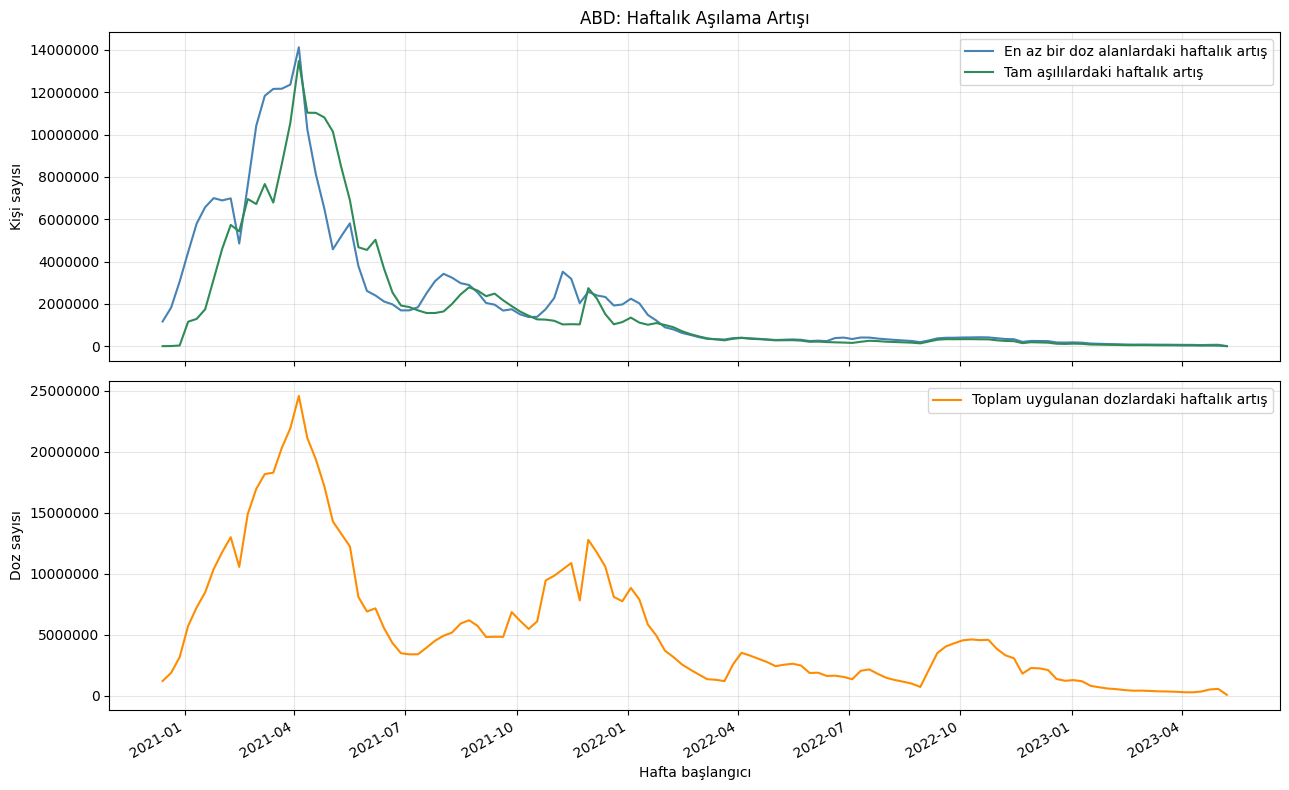

In [104]:
plot_weekly_vaccination = weekly_us_vaccination.dropna(
    subset=[
        'ilk_doz_haftalik_artis',
        'tam_asi_haftalik_artis',
        'toplam_doz_haftalik_artis'
    ]
).copy()

fig, (ax_kisiler, ax_dozlar) = plt.subplots(
    2,
    1,
    figsize=(13, 8),
    sharex=True
)

# Haftalık yeni kişi artışları
ax_kisiler.plot(
    plot_weekly_vaccination['hafta_baslangici'],
    plot_weekly_vaccination['ilk_doz_haftalik_artis'],
    color='steelblue',
    label='En az bir doz alanlardaki haftalık artış'
)

ax_kisiler.plot(
    plot_weekly_vaccination['hafta_baslangici'],
    plot_weekly_vaccination['tam_asi_haftalik_artis'],
    color='seagreen',
    label='Tam aşılılardaki haftalık artış'
)

ax_kisiler.set_title('ABD: Haftalık Aşılama Artışı')
ax_kisiler.set_ylabel('Kişi sayısı')
ax_kisiler.ticklabel_format(axis='y', style='plain')
ax_kisiler.grid(alpha=0.3)
ax_kisiler.legend()

# Haftalık toplam doz artışı
ax_dozlar.plot(
    plot_weekly_vaccination['hafta_baslangici'],
    plot_weekly_vaccination['toplam_doz_haftalik_artis'],
    color='darkorange',
    label='Toplam uygulanan dozlardaki haftalık artış'
)

ax_dozlar.set_xlabel('Hafta başlangıcı')
ax_dozlar.set_ylabel('Doz sayısı')
ax_dozlar.ticklabel_format(axis='y', style='plain')
ax_dozlar.grid(alpha=0.3)
ax_dozlar.legend()

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [105]:
weekly_vaccination_comparison = (
    df_countries[
        [
            'location',
            'date',
            'people_vaccinated_per_hundred',
            'people_fully_vaccinated_per_hundred'
        ]
    ]
    .dropna(
        subset=[
            'people_vaccinated_per_hundred',
            'people_fully_vaccinated_per_hundred'
        ]
    )
    .copy()
)

weekly_vaccination_comparison['hafta_baslangici'] = (
    weekly_vaccination_comparison['date']
    - pd.to_timedelta(
        weekly_vaccination_comparison['date'].dt.dayofweek,
        unit='D'
    )
)

weekly_vaccination_comparison = (
    weekly_vaccination_comparison
    .sort_values('date')
    .groupby(['location', 'hafta_baslangici'], as_index=False)
    .tail(1)
    .sort_values(['location', 'hafta_baslangici'])
    .copy()
)

print(weekly_vaccination_comparison.head(10).to_string(index=False))

   location       date  people_vaccinated_per_hundred  people_fully_vaccinated_per_hundred hafta_baslangici
Afghanistan 2021-05-11                           1.09                                 0.14       2021-05-10
Afghanistan 2021-05-20                           1.14                                 0.19       2021-05-17
Afghanistan 2021-05-30                           1.17                                 0.29       2021-05-24
Afghanistan 2021-06-03                           1.17                                 0.36       2021-05-31
Afghanistan 2021-06-08                           1.17                                 0.38       2021-06-07
Afghanistan 2021-06-14                           1.18                                 0.43       2021-06-14
Afghanistan 2021-06-27                           1.58                                 0.45       2021-06-21
Afghanistan 2021-06-30                           1.70                                 0.46       2021-06-28
Afghanistan 2021-07-11      

In [106]:
vaccination_week_coverage = (
    weekly_vaccination_comparison
    .groupby('hafta_baslangici')['location']
    .nunique()
    .sort_values(ascending=False)
)

print(vaccination_week_coverage.head(10))

hafta_baslangici
2021-09-06    173
2021-09-20    171
2021-08-30    169
2021-08-16    166
2021-07-19    165
2021-10-25    165
2021-09-27    165
2021-10-18    165
2021-10-04    164
2021-11-01    163
Name: location, dtype: int64


In [107]:
selected_week = pd.Timestamp('2021-09-06')

selected_vaccination_week = (
    weekly_vaccination_comparison.loc[
        weekly_vaccination_comparison['hafta_baslangici'].eq(selected_week),
        [
            'location',
            'people_vaccinated_per_hundred',
            'people_fully_vaccinated_per_hundred'
        ]
    ]
    .sort_values(
        'people_fully_vaccinated_per_hundred',
        ascending=False
    )
    .head(15)
    .sort_values('people_fully_vaccinated_per_hundred')
)

print(selected_vaccination_week.to_string(index=False))

            location  people_vaccinated_per_hundred  people_fully_vaccinated_per_hundred
             Iceland                          75.22                                71.35
             Belgium                          73.44                                71.48
             Ireland                          75.55                                71.66
      Cayman Islands                          76.88                                72.80
               Spain                          78.25                                74.22
             Bahrain                          78.56                                74.58
             Uruguay                          78.35                                74.74
         Isle of Man                          77.33                                74.80
            Portugal                          87.25                                76.26
           Singapore                          82.37                                77.16
               Malta 

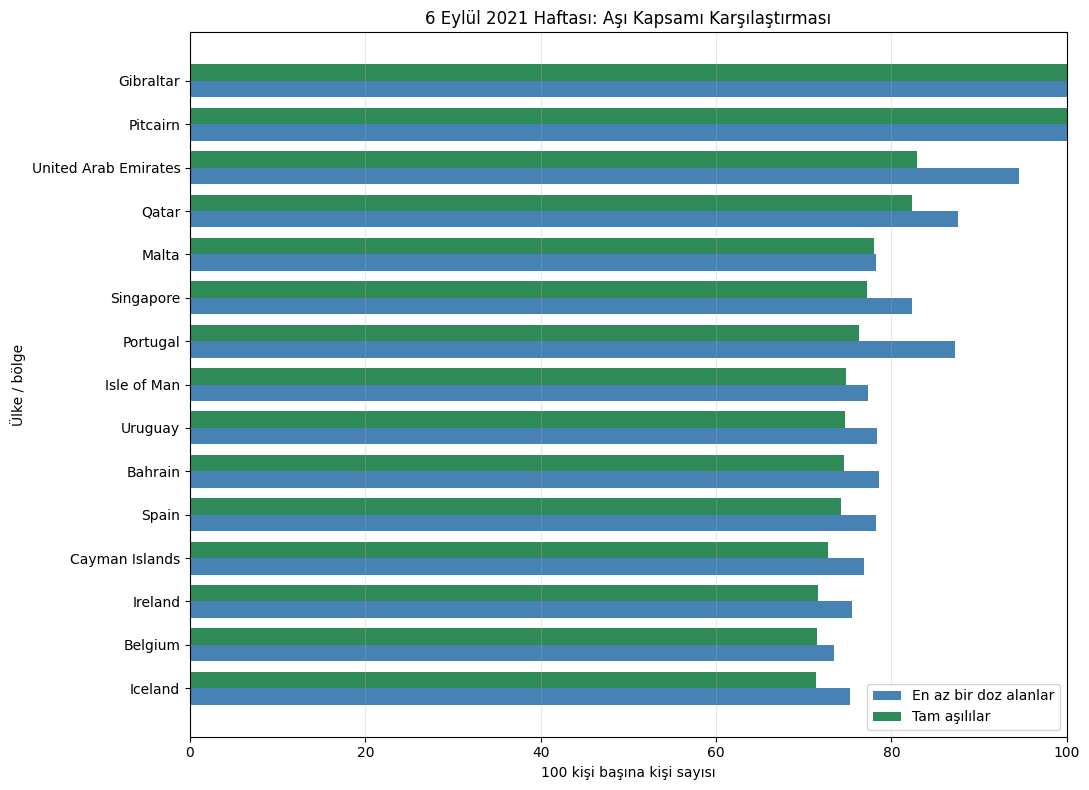

In [108]:
y = np.arange(len(selected_vaccination_week))
bar_height = 0.38

fig, ax = plt.subplots(figsize=(11, 8))

ax.barh(
    y - bar_height / 2,
    selected_vaccination_week['people_vaccinated_per_hundred'],
    height=bar_height,
    color='steelblue',
    label='En az bir doz alanlar'
)

ax.barh(
    y + bar_height / 2,
    selected_vaccination_week['people_fully_vaccinated_per_hundred'],
    height=bar_height,
    color='seagreen',
    label='Tam aşılılar'
)

ax.set_yticks(y)
ax.set_yticklabels(selected_vaccination_week['location'])

ax.set_title('6 Eylül 2021 Haftası: Aşı Kapsamı Karşılaştırması')
ax.set_xlabel('100 kişi başına kişi sayısı')
ax.set_ylabel('Ülke / bölge')

ax.set_xlim(0, 100)
ax.grid(axis='x', alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

In [109]:
#Hastane yatakları kapasitesi,hastanede yatan hasta sayısı,o gün yoğun bakımda olanlar
hospital_columns = [
    'location',
    'date',
    'hospital_beds_per_thousand',
    'hosp_patients',
    'icu_patients'
]

print(df_countries[hospital_columns].info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396268 entries, 0 to 396267
Data columns (total 5 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   location                    396268 non-null  object        
 1   date                        396268 non-null  datetime64[ns]
 2   hospital_beds_per_thousand  287991 non-null  float64       
 3   hosp_patients               35442 non-null   float64       
 4   icu_patients                34825 non-null   float64       
dtypes: datetime64[ns](1), float64(3), object(1)
memory usage: 15.1+ MB
None


In [110]:
#hospital_beds_per_thousand:1000 kişi başına hastane yatak kapasitesi
#hosp_patients:O gün hastanede yatan COVID-19 hasta sayısı.
#icu_patients:O gün yoğun bakımda bulunan COVID-19 hasta sayısı.
bed_check = df_countries.groupby('location').agg(
    toplam_satir=('date', 'size'),
    dolu_yatak_kaydi=('hospital_beds_per_thousand', 'count'),
    farkli_yatak_degeri=('hospital_beds_per_thousand', 'nunique'),
    en_dusuk_yatak=('hospital_beds_per_thousand', 'min'),
    en_yuksek_yatak=('hospital_beds_per_thousand', 'max')
)

print(
    bed_check
    .sort_values('dolu_yatak_kaydi')
    .head(15)
)

                                 toplam_satir  dolu_yatak_kaydi  \
location                                                          
American Samoa                           1674                 0   
Anguilla                                 1674                 0   
Angola                                   1674                 0   
Andorra                                  1674                 0   
Aruba                                    1674                 0   
British Virgin Islands                   1674                 0   
Bonaire Sint Eustatius and Saba          1674                 0   
Bermuda                                  1674                 0   
Chad                                     1674                 0   
Cote d'Ivoire                            1674                 0   
Democratic Republic of Congo             1674                 0   
Curacao                                  1674                 0   
Cook Islands                             1674                 

In [181]:
booster_coverage = (
    df_countries
    .groupby('location')
    .agg(
        toplam_satir=('date', 'size'),
        dolu_hatirlatma_dozu_kaydi=('total_boosters', 'count'),
        dolu_hatirlatma_orani_kaydi=(
            'total_boosters_per_hundred',
            'count'
        )
    )
)

valid_booster_range = (
    df_countries[
        df_countries['total_boosters'].notna()
    ]
    .groupby('location')
    .agg(
        ilk_hatirlatma_dozu_tarihi=('date', 'min'),
        son_hatirlatma_dozu_tarihi=('date', 'max')
    )
)

booster_coverage = booster_coverage.join(valid_booster_range)

booster_coverage['bos_hatirlatma_dozu_kaydi'] = (
    booster_coverage['toplam_satir']
    - booster_coverage['dolu_hatirlatma_dozu_kaydi']
)

print(
    booster_coverage
    .sort_values('dolu_hatirlatma_dozu_kaydi', ascending=False)
    .head(20)
)

             toplam_satir  dolu_hatirlatma_dozu_kaydi  \
location                                                
Estonia              1682                        1258   
Canada               1674                        1204   
Czechia              1682                        1182   
Argentina            1678                        1125   
Malaysia             1684                        1068   
Lithuania            1684                        1033   
Belgium              1674                         990   
Greece               1674                         952   
Ireland              1674                         929   
Hong Kong            1654                         917   
France               1674                         907   
India                1682                         887   
Switzerland          1674                         883   
Peru                 1674                         787   
Italy                1677                         778   
New Zealand          1681      

In [182]:
us_booster_data = (
    df_countries[
        df_countries['location'] == 'United States'
    ][
        [
            'date',
            'total_boosters',
            'total_boosters_per_hundred',
            'people_fully_vaccinated'
        ]
    ]
    .sort_values('date')
)

us_booster_valid = us_booster_data[
    us_booster_data['total_boosters'].notna()
].copy()

expected_dates = pd.date_range(
    us_booster_valid['date'].min(),
    us_booster_valid['date'].max(),
    freq='D'
)

missing_booster_dates = expected_dates.difference(
    us_booster_valid['date']
)

print('İlk hatırlatma dozu kaydı:', us_booster_valid['date'].min())
print('Son hatırlatma dozu kaydı:', us_booster_valid['date'].max())
print('Hatırlatma dozu bulunan gün:', len(us_booster_valid))
print('Aradaki eksik gün sayısı:', len(missing_booster_dates))
print(missing_booster_dates[:10])

İlk hatırlatma dozu kaydı: 2021-02-04 00:00:00
Son hatırlatma dozu kaydı: 2022-09-01 00:00:00
Hatırlatma dozu bulunan gün: 575
Aradaki eksik gün sayısı: 0
DatetimeIndex([], dtype='datetime64[ns]', freq='D')


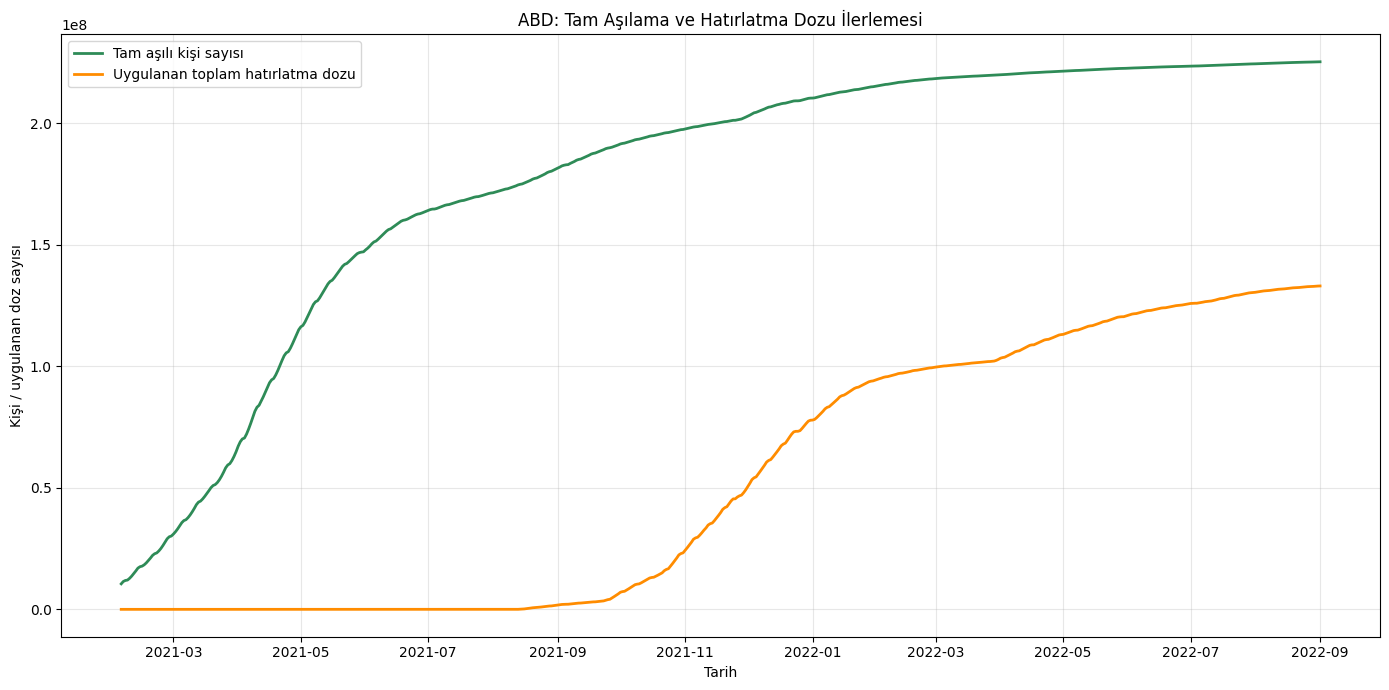

In [183]:
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(
    us_booster_valid['date'],
    us_booster_valid['people_fully_vaccinated'],
    color='seagreen',
    linewidth=2,
    label='Tam aşılı kişi sayısı'
)

ax.plot(
    us_booster_valid['date'],
    us_booster_valid['total_boosters'],
    color='darkorange',
    linewidth=2,
    label='Uygulanan toplam hatırlatma dozu'
)

ax.set_title(
    'ABD: Tam Aşılama ve Hatırlatma Dozu İlerlemesi'
)
ax.set_xlabel('Tarih')
ax.set_ylabel('Kişi / uygulanan doz sayısı')
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

In [184]:
us_booster_weekly = (
    us_booster_valid
    .assign(
        hafta_baslangici=(
            us_booster_valid['date']
            - pd.to_timedelta(
                us_booster_valid['date'].dt.dayofweek,
                unit='D'
            )
        )
    )
    .sort_values('date')
    .groupby('hafta_baslangici', as_index=False)
    .last()
)

us_booster_weekly['haftalik_hatirlatma_dozu_artisi'] = (
    us_booster_weekly['total_boosters']
    .diff()
)

print(
    us_booster_weekly[
        [
            'hafta_baslangici',
            'total_boosters',
            'haftalik_hatirlatma_dozu_artisi'
        ]
    ]
    .head(10)
)

  hafta_baslangici  total_boosters  haftalik_hatirlatma_dozu_artisi
0       2021-02-01             2.0                              NaN
1       2021-02-08             4.0                              2.0
2       2021-02-15             6.0                              2.0
3       2021-02-22            11.0                              5.0
4       2021-03-01            15.0                              4.0
5       2021-03-08            19.0                              4.0
6       2021-03-15            23.0                              4.0
7       2021-03-22            38.0                             15.0
8       2021-03-29            54.0                             16.0
9       2021-04-05            72.0                             18.0


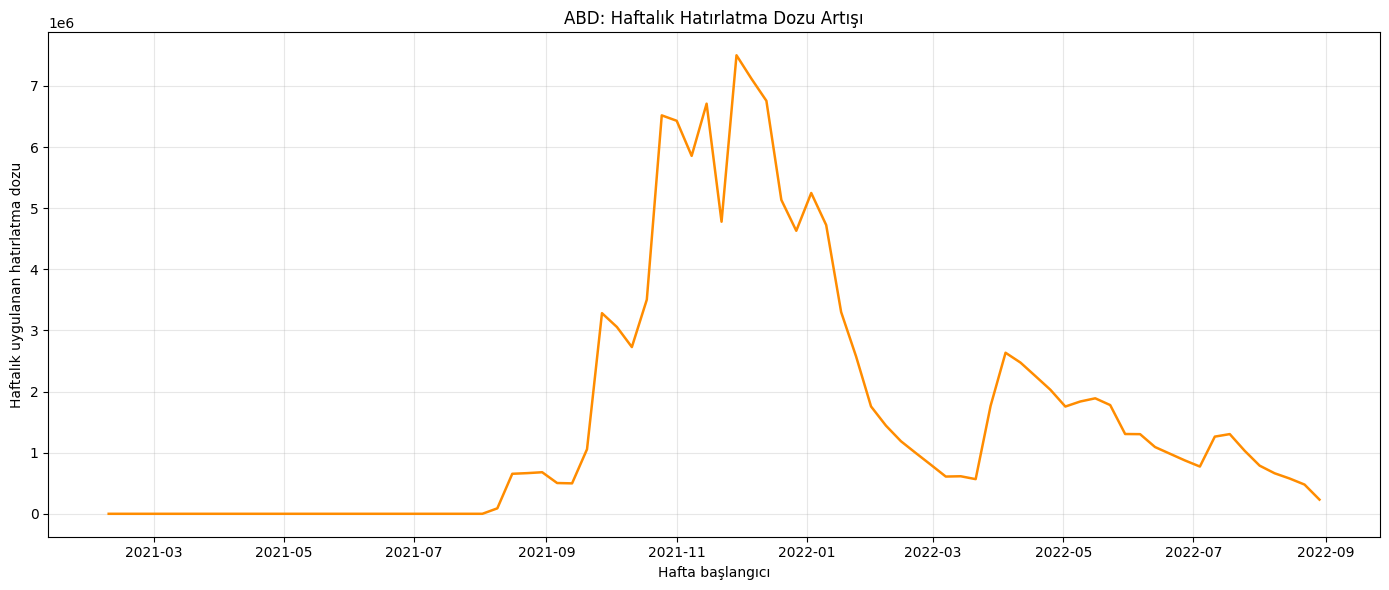

In [185]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    us_booster_weekly['hafta_baslangici'],
    us_booster_weekly['haftalik_hatirlatma_dozu_artisi'],
    color='darkorange',
    linewidth=1.8
)

ax.set_title('ABD: Haftalık Hatırlatma Dozu Artışı')
ax.set_xlabel('Hafta başlangıcı')
ax.set_ylabel('Haftalık uygulanan hatırlatma dozu')

ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()